In [10]:
#define the origenal image
import cv2
import numpy as np
import matplotlib.pyplot as plt
img = np.array([[10,20,30],[40,50,60],[70,80,90]])


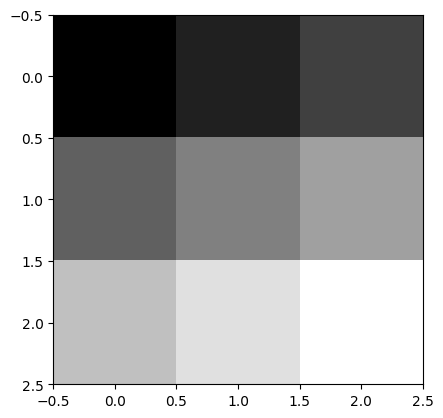

In [11]:
#display the image
plt.imshow(img,cmap='gray')
plt.show()

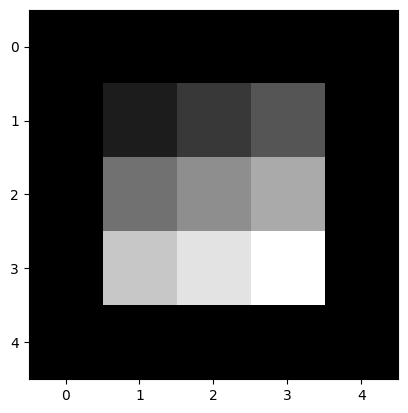

In [12]:
#step 3 zero padding
img_padded = np.pad(img,((1,1),(1,1)),'constant',constant_values=0)
#display the padded image
plt.imshow(img_padded,cmap='gray')

[[0.11111111 0.11111111 0.11111111]
 [0.11111111 0.11111111 0.11111111]
 [0.11111111 0.11111111 0.11111111]]


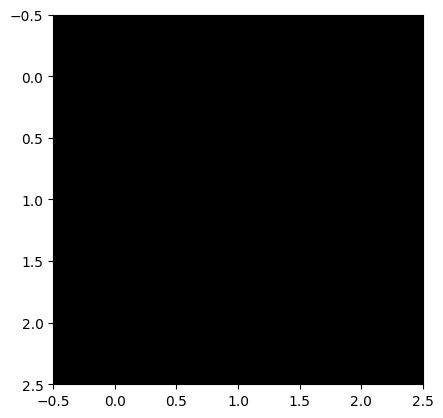

In [13]:
#step 5 define the kernel
#kernel = 1/9*np.array([[1,1,1],[1,1,1],[1,1,1]])
kernal = np.ones((3,3))/9
print(kernal)
plt.imshow(kernal,cmap='gray')

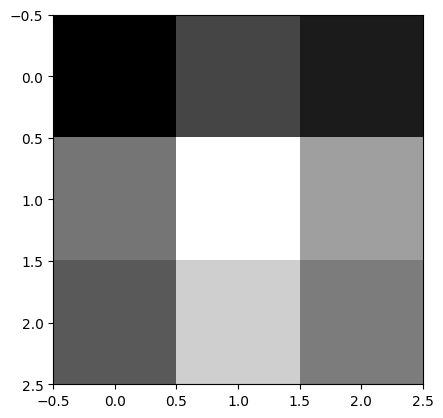

In [14]:
#step 6 apply the convelution operation
def convolve(img, kernel):
    #get the dimensions of the image and kernel
    img_h, img_w = img.shape
    kernel_h, kernel_w = kernel.shape
    #calculate the padding size
    pad_h = kernel_h // 2
    pad_w = kernel_w // 2
    #pad the image with zeros
    img_padded = np.pad(img, ((pad_h, pad_h), (pad_w, pad_w)), mode='constant', constant_values=0)
    #create an empty array to store the convolved image
    convolved_img = np.zeros_like(img)
    #perform convolution
    for i in range(img_h):
        for j in range(img_w):
            #extract the region of interest
            roi = img_padded[i:i+kernel_h, j:j+kernel_w]
            #perform element-wise multiplication and sum
            convolved_img[i, j] = np.sum(roi * kernel)
    return convolved_img
#apply the convolution operation
convolved_img = convolve(img, kernal)
#display the convolved image
plt.imshow(convolved_img,cmap='gray')
plt.show()

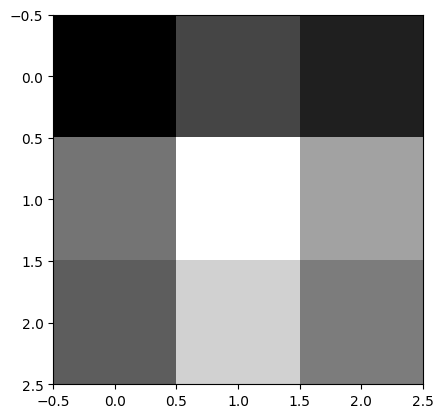

In [15]:
#get the dimensions of the image and kernel
img_h , img_w = img.shape
kernel_h , kernel_w = kernal.shape
#initialize the output image of zeros 
output_image = np.zeros((img_h, img_w))
#slide the kernel over the image
for i in range(img_h):
    for j in range(img_w):
        #extract the region of interest
        region = img_padded[i:i+kernel_h, j:j+kernel_w]
        #perform element-wise multiplication and sum
        output_image[i, j] = np.sum(region * kernal)
#display the output image
plt.imshow(output_image,cmap='gray')
plt.show()

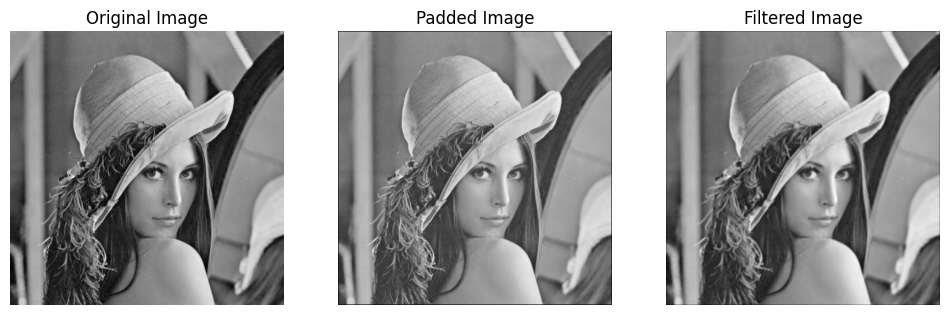

In [16]:
import numpy as np
import matplotlib.pyplot as plt

# Load image
image = plt.imread(r"C:\BDA\digital image processing\Dip_class\dip_img\lena_image.png")

# Convert to grayscale
if len(image.shape) == 3:
    image = np.mean(image, axis=2)

# Average kernel
kernel = np.ones((3,3)) / 9

# Zero padding
padded = np.pad(image, 1, mode='constant', constant_values=0)

# Output image
output = np.zeros_like(image, dtype=float)

# Convolution
for i in range(image.shape[0]):
    for j in range(image.shape[1]):
        region = padded[i:i+3, j:j+3]
        output[i,j] = np.sum(region * kernel)

# Display
plt.figure(figsize=(12,6))

plt.subplot(1,3,1)
plt.imshow(image, cmap='gray')
plt.title("Original Image")
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(padded, cmap='gray')
plt.title("Padded Image")
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(output, cmap='gray')
plt.title("Filtered Image")
plt.axis('off')

plt.show()

MSE : 0.0006187317760368424
PSNR : 80.21577940333466 dB


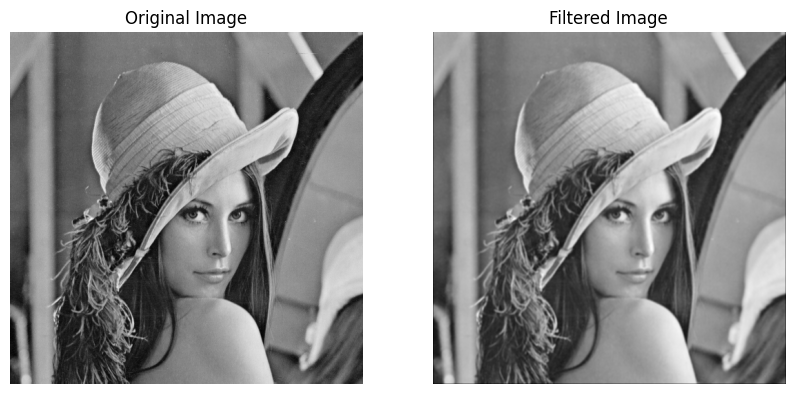

In [17]:
import numpy as np
import matplotlib.pyplot as plt

# ======================
# STEP 1: Load Image
# ======================
image = plt.imread(r"C:\BDA\digital image processing\Dip_class\dip_img\lena_image.png")   # put your image name

# Convert RGB → Grayscale
if len(image.shape) == 3:
    image = np.mean(image, axis=2)

# Convert to float (important for calculations)
image = image.astype(float)

# ======================
# STEP 2: Average Kernel
# ======================
kernel = np.ones((3,3)) / 9

# ======================
# STEP 3: Zero Padding
# ======================
padded = np.pad(image, 1, mode='constant', constant_values=0)

# ======================
# STEP 4: Filtering (Convolution)
# ======================
output = np.zeros_like(image)

for i in range(image.shape[0]):
    for j in range(image.shape[1]):

        region = padded[i:i+3, j:j+3]
        output[i,j] = np.sum(region * kernel)

# ======================
# STEP 5: MSE Calculation
# ======================
mse = np.mean((image - output) ** 2)

# ======================
# STEP 6: PSNR Calculation
# ======================
MAX_PIXEL = 255.0

if mse == 0:
    psnr = float('inf')
else:
    psnr = 10 * np.log10((MAX_PIXEL**2) / mse)

# ======================
# STEP 7: Print Statistics
# ======================
print("MSE :", mse)
print("PSNR :", psnr, "dB")

# ======================
# STEP 8: Display Images
# ======================
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(image, cmap='gray')
plt.title("Original Image")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(output, cmap='gray')
plt.title("Filtered Image")
plt.axis('off')

plt.show()

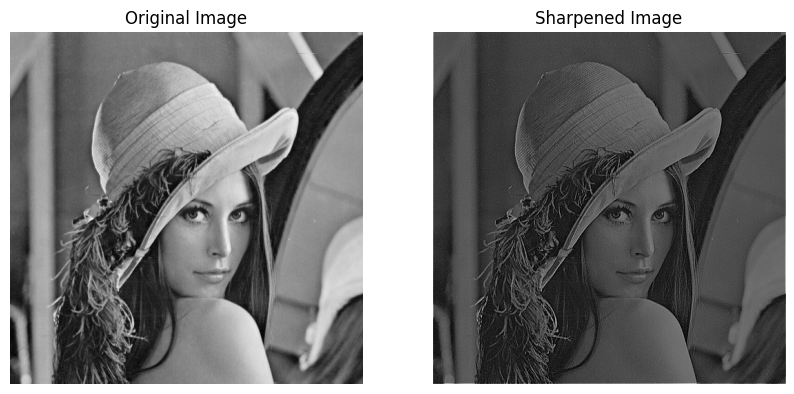

In [18]:
import numpy as np
import matplotlib.pyplot as plt

# ======================
# STEP 1: Load Image
# ======================
image = plt.imread(r"C:\BDA\digital image processing\Dip_class\dip_img\lena_image.png")

# Convert RGB → Grayscale
if len(image.shape) == 3:
    image = np.mean(image, axis=2)

image = image.astype(float)

# ======================
# STEP 2: SHARPEN KERNEL
# ======================
kernel = np.array([[0, -1, 0],
                   [-1, 5, -1],
                   [0, -1, 0]])

# ======================
# STEP 3: Zero Padding
# ======================
padded = np.pad(image, 1, mode='constant', constant_values=0)

# ======================
# STEP 4: Convolution
# ======================
output = np.zeros_like(image)

for i in range(image.shape[0]):
    for j in range(image.shape[1]):

        region = padded[i:i+3, j:j+3]
        output[i,j] = np.sum(region * kernel)

# Clip values (important)
output = np.clip(output, 0, 255)

# ======================
# STEP 5: Display
# ======================
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(image, cmap='gray')
plt.title("Original Image")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(output, cmap='gray')
plt.title("Sharpened Image")
plt.axis('off')

plt.show()